# IS 477 Project - Military Spending and Conflict Intensity in Europe and Central Asia, 2018-2024
Connor Slattery and Jessica Zheng

Load and clean three datasets, merge them, and make visualizations. Run cells top to bottom.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

RAW_DIR = Path(".")   # current project folder
PROC_DIR = RAW_DIR / "processed"
FIG_DIR  = RAW_DIR / "figures"

PROC_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SIPRI_FILE = RAW_DIR / "SIPRI-Milex-data-2017-2025.xlsx"
WB_FILE    = RAW_DIR / "API_MS.MIL.XPND.GD.ZS_DS2_en_csv_v2_211.csv"
ACLED_FILE = RAW_DIR / "Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-28.xlsx"

for f in [SIPRI_FILE, WB_FILE, ACLED_FILE]:
    status = "found" if f.exists() else "MISSING"
    print(f.name, "-", status)

SIPRI-Milex-data-2017-2025.xlsx - found
API_MS.MIL.XPND.GD.ZS_DS2_en_csv_v2_211.csv - found
Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-28.xlsx - found


## Part 1 - ACLED Data

ACLED tracks conflict events by week and location. Each row is one admin region for one week.

Source: https://acleddata.com/aggregated/aggregated-data-europe-and-central-asia

In [2]:
acled_raw = pd.read_excel(ACLED_FILE, engine="openpyxl")
print("shape:", acled_raw.shape)
acled_raw.head()

shape: (118846, 13)


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,2026-02-28,Europe,Akrotiri and Dhekelia,Akrotiri,Explosions/Remote violence,Air/drone strike,1,0,649.0,Political violence,4120.0,34.6,32.9586
1,2018-06-09,Europe,Akrotiri and Dhekelia,Akrotiri,Protests,Peaceful protest,1,0,183.0,Demonstrations,4120.0,34.6,32.9586
2,2022-02-19,Europe,Akrotiri and Dhekelia,Akrotiri,Protests,Peaceful protest,1,0,193.0,Demonstrations,4120.0,34.6,32.9586
3,2022-05-28,Europe,Akrotiri and Dhekelia,Akrotiri,Protests,Peaceful protest,1,0,89.0,Demonstrations,4120.0,34.6,32.9586
4,2024-01-13,Europe,Akrotiri and Dhekelia,Akrotiri,Protests,Peaceful protest,1,0,197.0,Demonstrations,4120.0,34.6,32.9586


In [3]:
print(acled_raw.dtypes)
print()
print(acled_raw.isnull().sum())

WEEK                   datetime64[ns]
REGION                         object
COUNTRY                        object
ADMIN1                         object
EVENT_TYPE                     object
SUB_EVENT_TYPE                 object
EVENTS                          int64
FATALITIES                      int64
POPULATION_EXPOSURE           float64
DISORDER_TYPE                  object
ID                            float64
CENTROID_LATITUDE             float64
CENTROID_LONGITUDE            float64
dtype: object

WEEK                       0
REGION                     0
COUNTRY                    0
ADMIN1                     8
EVENT_TYPE                 0
SUB_EVENT_TYPE             0
EVENTS                     0
FATALITIES                 0
POPULATION_EXPOSURE    15229
DISORDER_TYPE              0
ID                        21
CENTROID_LATITUDE          0
CENTROID_LONGITUDE         0
dtype: int64


In [4]:
print(acled_raw["EVENT_TYPE"].value_counts())
print()
print("years:", acled_raw["WEEK"].dt.year.min(), "to", acled_raw["WEEK"].dt.year.max())
print("countries:", acled_raw["COUNTRY"].nunique())

EVENT_TYPE
Protests                      78402
Strategic developments        14148
Explosions/Remote violence     9674
Riots                          6762
Battles                        5338
Violence against civilians     4522
Name: count, dtype: int64

years: 2017 to 2026
countries: 61


In [5]:
acled_raw.groupby("COUNTRY")["EVENTS"].sum().sort_values(ascending=False).head(10)

COUNTRY
Ukraine           308984
Russia             55603
France             45570
Italy              28978
Germany            27424
Spain              24747
Azerbaijan         19024
United Kingdom      9467
Poland              8928
Greece              7994
Name: EVENTS, dtype: int64

## Part 2 - Cleaning ACLED

In [6]:
acled = acled_raw.copy()
acled["YEAR"] = acled["WEEK"].dt.year
acled = acled[acled["YEAR"] >= 2018]
acled = acled[acled["YEAR"] <= 2024]
acled = acled.reset_index(drop=True)
print("rows after filter:", len(acled))

rows after filter: 95379


In [7]:
acled = acled.drop(columns=["ID"])
acled["POPULATION_EXPOSURE"] = acled["POPULATION_EXPOSURE"].fillna(0)
acled["ADMIN1"] = acled["ADMIN1"].fillna("Unknown")
print("nulls remaining:")
print(acled.isnull().sum())

nulls remaining:
WEEK                   0
REGION                 0
COUNTRY                0
ADMIN1                 0
EVENT_TYPE             0
SUB_EVENT_TYPE         0
EVENTS                 0
FATALITIES             0
POPULATION_EXPOSURE    0
DISORDER_TYPE          0
CENTROID_LATITUDE      0
CENTROID_LONGITUDE     0
YEAR                   0
dtype: int64


In [8]:
acled["COUNTRY"] = acled["COUNTRY"].replace("Russia", "Russian Federation")
acled["COUNTRY"] = acled["COUNTRY"].replace("Bosnia and Herzegovina", "Bosnia-Herzegovina")
acled["COUNTRY"] = acled["COUNTRY"].replace("North Macedonia", "Macedonia")
acled["COUNTRY"] = acled["COUNTRY"].replace("Czech Republic", "Czechia")

for c in ["Ukraine", "Russian Federation", "Armenia", "Azerbaijan"]:
    n = acled[acled["COUNTRY"] == c]["EVENTS"].sum()
    print(c, n)

Ukraine 208655
Russian Federation 29181
Armenia 6889
Azerbaijan 18782


In [9]:
base = acled.groupby(["COUNTRY", "YEAR"]).agg(
    total_events=("EVENTS", "sum"),
    total_fatalities=("FATALITIES", "sum"),
    total_pop_exposure=("POPULATION_EXPOSURE", "sum"),
)
base = base.reset_index()
base = base.rename(columns={"COUNTRY": "country", "YEAR": "year"})

event_pivot = acled.groupby(["COUNTRY", "YEAR", "EVENT_TYPE"])["EVENTS"].sum()
event_pivot = event_pivot.unstack(fill_value=0)
event_pivot = event_pivot.reset_index()
event_pivot.columns.name = None

new_cols = ["country", "year"]
for c in event_pivot.columns[2:]:
    clean = c.lower().replace(" ", "_").replace("/", "_")
    new_cols.append(clean)
event_pivot.columns = new_cols

acled_clean = base.merge(event_pivot, on=["country", "year"], how="left")
print("shape:", acled_clean.shape)
acled_clean.head()

shape: (359, 11)


,country,year,total_events,total_fatalities,total_pop_exposure,battles,explosions_remote_violence,protests,riots,strategic_developments,violence_against_civilians
0,Akrotiri and Dhekelia,2018,1,0,183.0,0,0,1,0,0,0
1,Akrotiri and Dhekelia,2019,1,0,0.0,0,0,0,0,1,0
2,Akrotiri and Dhekelia,2020,1,0,0.0,0,0,0,0,1,0
3,Akrotiri and Dhekelia,2021,3,0,731.0,0,0,2,1,0,0
4,Akrotiri and Dhekelia,2022,2,0,282.0,0,0,2,0,0,0


In [10]:
acled_clean.to_csv(PROC_DIR / "acled_clean.csv", index=False)
print("saved acled_clean.csv")

saved acled_clean.csv


## Part 3 - SIPRI Data

SIPRI tracks military spending by country. We use spending in constant dollars and spending as a percent of GDP.

Source: https://milex.sipri.org/sipri

In [11]:
YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

REGION_HEADERS = [
    "Asia & Oceania", "Central Asia", "Europe", "Central Europe",
    "Eastern Europe", "Western Europe", "North Africa", "Sub-Saharan Africa",
    "The Americas", "North America", "Central America and the Caribbean",
    "South America", "Middle East", "South Asia", "East Asia", "Oceania",
    "Czechoslovakia",
]

def parse_sipri_sheet(sheet_name, value_col):
    df_raw = pd.read_excel(SIPRI_FILE, sheet_name=sheet_name, header=None, engine="openpyxl")

    header_row = 0
    for i, row in df_raw.iterrows():
        if str(row.iloc[0]).strip() == "Country":
            header_row = i
            break

    df = pd.read_excel(SIPRI_FILE, sheet_name=sheet_name, header=header_row, engine="openpyxl")

    new_col_names = {}
    for col in df.columns:
        if isinstance(col, (int, float)) and not isinstance(col, bool):
            if int(col) in YEARS:
                new_col_names[col] = str(int(col))
    df = df.rename(columns=new_col_names)
    df = df.rename(columns={df.columns[0]: "country"})

    df = df[df["country"].notna()]
    df["country"] = df["country"].astype(str).str.strip()
    df = df[~df["country"].isin(REGION_HEADERS)]
    df = df[df["country"] != ""]

    keep_cols = ["country"]
    for y in YEARS:
        if str(y) in df.columns:
            keep_cols.append(str(y))
    df = df[keep_cols]

    df_long = df.melt(id_vars="country", var_name="year", value_name=value_col)
    df_long["year"] = df_long["year"].astype(int)

    missing_codes = ["...", ". .", "xxx", "x", ""]
    for code in missing_codes:
        df_long[value_col] = df_long[value_col].replace(code, np.nan)

    df_long[value_col] = pd.to_numeric(df_long[value_col], errors="coerce")
    df_long = df_long[df_long["year"] >= 2018]
    df_long = df_long[df_long["year"] <= 2024]
    df_long = df_long.reset_index(drop=True)

    return df_long

In [12]:
df_usd = parse_sipri_sheet("Constant (2024) US$", "milex_constant_usd_m")
df_usd["country"] = df_usd["country"].replace("Russia", "Russian Federation")
df_usd["country"] = df_usd["country"].replace("Bosnia and Herzegovina", "Bosnia-Herzegovina")
df_usd["country"] = df_usd["country"].replace("North Macedonia", "Macedonia")

df_gdp = parse_sipri_sheet("Share of GDP", "milex_share_gdp")
df_gdp["country"] = df_gdp["country"].replace("Russia", "Russian Federation")
df_gdp["country"] = df_gdp["country"].replace("Bosnia and Herzegovina", "Bosnia-Herzegovina")
df_gdp["country"] = df_gdp["country"].replace("North Macedonia", "Macedonia")

if df_gdp["milex_share_gdp"].dropna().max() < 2.0:
    df_gdp["milex_share_gdp"] = df_gdp["milex_share_gdp"] * 100

print("usd shape:", df_usd.shape)
print("gdp shape:", df_gdp.shape)
df_usd.head()

usd shape: (329, 3)
gdp shape: (329, 3)


,country,year,milex_constant_usd_m
0,Kazakhstan,2018,1813.991630
1,Tajikistan,2018,97.865296
2,Turkmenistan,2018,NaN
3,Uzbekistan,2018,1749.977932
4,Albania,2018,220.587521


In [13]:
sipri_clean = df_usd.merge(df_gdp, on=["country", "year"], how="outer")
sipri_clean.to_csv(PROC_DIR / "sipri_clean.csv", index=False)
print("saved sipri_clean.csv")
sipri_clean[sipri_clean["country"] == "Ukraine"]

saved sipri_clean.csv


,country,year,milex_constant_usd_m,milex_share_gdp
308,Ukraine,2018,5782.799949,3.635166
309,Ukraine,2019,6700.552182,4.067938
310,Ukraine,2020,7436.048124,4.400315
311,Ukraine,2021,6882.835827,3.425492
312,Ukraine,2022,41205.164991,25.642410
313,Ukraine,2023,64908.025327,36.528173
314,Ukraine,2024,66784.434887,34.481530


## Part 4 - World Bank Data

Second source for military spending as % of GDP. Also our only source for USA and Canada spending.

Source: https://data.worldbank.org/indicator/MS.MIL.XPND.GD.ZS

In [14]:
wb_raw = pd.read_csv(WB_FILE, skiprows=4)

cols_to_keep = []
for col in wb_raw.columns:
    if not col.startswith("Unnamed"):
        cols_to_keep.append(col)
wb_raw = wb_raw[cols_to_keep]

wb_raw = wb_raw.rename(columns={"Country Name": "country_name", "Country Code": "country_code"})
print("shape:", wb_raw.shape)
wb_raw[["country_name", "country_code", "2018", "2022", "2023", "2024"]].head()

shape: (266, 70)


,country_name,country_code,2018,2022,2023,2024
0,Aruba,ABW,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,1.125957,1.118534,1.044194,0.976005
2,Afghanistan,AFG,1.006746,NaN,NaN,NaN
3,Africa Western and Central,AFW,0.837846,0.922683,1.133873,1.169258
4,Angola,AGO,1.955787,1.410164,1.407255,1.000492


In [15]:
ECA_ISO3 = [
    "KAZ", "KGZ", "TJK", "TKM", "UZB",
    "ARM", "AZE", "BLR", "GEO", "MDA", "RUS", "UKR",
    "ALB", "BIH", "BGR", "HRV", "EST", "HUN", "XKX", "LVA", "LTU",
    "MKD", "MNE", "POL", "ROU", "SRB", "SVK", "SVN",
    "AUT", "BEL", "CYP", "DNK", "FIN", "FRA", "DEU", "GRC", "ISL",
    "IRL", "ITA", "LUX", "MLT", "NLD", "NOR", "PRT", "ESP", "SWE",
    "CHE", "GBR", "TUR",
    "USA", "CAN",
]

wb = wb_raw[wb_raw["country_code"].isin(ECA_ISO3)].copy()

year_cols = []
for col in wb.columns:
    if col.isdigit():
        year_cols.append(col)

wb_long = wb[["country_name", "country_code"] + year_cols].melt(
    id_vars=["country_name", "country_code"],
    var_name="year",
    value_name="wb_milex_pct_gdp"
)
wb_long["year"] = wb_long["year"].astype(int)
wb_long = wb_long[wb_long["year"] >= 2018]
wb_long = wb_long[wb_long["year"] <= 2024]
wb_long = wb_long.dropna(subset=["wb_milex_pct_gdp"])
wb_long = wb_long.reset_index(drop=True)

# fix naming inconsistencies between World Bank and SIPRI/ACLED
wb_long["country_name"] = wb_long["country_name"].replace("Bosnia and Herzegovina", "Bosnia-Herzegovina")
wb_long["country_name"] = wb_long["country_name"].replace("North Macedonia", "Macedonia")
wb_long["country_name"] = wb_long["country_name"].replace("Kyrgyz Republic", "Kyrgyzstan")
wb_long["country_name"] = wb_long["country_name"].replace("Turkiye", "Turkey")
wb_long["country_name"] = wb_long["country_name"].replace("Slovak Republic", "Slovakia")

print("shape:", wb_long.shape)
print("USA rows:", len(wb_long[wb_long["country_name"] == "United States"]))
print("Canada rows:", len(wb_long[wb_long["country_name"] == "Canada"]))
print("Turkey rows:", len(wb_long[wb_long["country_name"] == "Turkey"]))
wb_long.head()

shape: (337, 4)
USA rows: 7
Canada rows: 7
Turkey rows: 7


,country_name,country_code,year,wb_milex_pct_gdp
0,Albania,ALB,2018,1.160545
1,Armenia,ARM,2018,4.119886
2,Austria,AUT,2018,0.748993
3,Azerbaijan,AZE,2018,3.549293
4,Belgium,BEL,2018,0.892442


In [16]:
wb_long.to_csv(PROC_DIR / "worldbank_clean.csv", index=False)
print("saved worldbank_clean.csv")

saved worldbank_clean.csv


## Part 5 - Merging Everything

Join all three datasets on country + year. SIPRI is the base. USA and Canada are added to the spine manually since they have no SIPRI or ACLED data but do have World Bank spending data.

In [17]:
sipri_pairs = sipri_clean[["country", "year"]].drop_duplicates()
acled_pairs = acled_clean[["country", "year"]].drop_duplicates()
spine = pd.concat([sipri_pairs, acled_pairs])
spine = spine.drop_duplicates()

extra_rows = []
for country in ["United States", "Canada"]:
    for year in range(2018, 2025):
        extra_rows.append({"country": country, "year": year})

extra = pd.DataFrame(extra_rows)
spine = pd.concat([spine, extra])
spine = spine.drop_duplicates()
spine = spine.sort_values(["country", "year"])
spine = spine.reset_index(drop=True)

print("spine:", len(spine), "rows,", spine["country"].nunique(), "countries")

spine: 408 rows, 63 countries


In [18]:
df = spine.merge(sipri_clean, on=["country", "year"], how="left")
df["sipri_available"] = 0
df.loc[df["milex_constant_usd_m"].notna(), "sipri_available"] = 1

wb_merge = wb_long.rename(columns={"country_name": "country"})
wb_merge = wb_merge[["country", "country_code", "year", "wb_milex_pct_gdp"]]
df = df.merge(wb_merge, on=["country", "year"], how="left")
df["worldbank_available"] = 0
df.loc[df["wb_milex_pct_gdp"].notna(), "worldbank_available"] = 1

df = df.merge(acled_clean, on=["country", "year"], how="left")
df["acled_available"] = 0
df.loc[df["total_events"].notna(), "acled_available"] = 1

print("shape:", df.shape)
print("sipri rows:", df["sipri_available"].sum())
print("worldbank rows:", df["worldbank_available"].sum())
print("acled rows:", df["acled_available"].sum())

shape: (408, 18)
sipri rows: 316
worldbank rows: 330
acled rows: 359


In [19]:
df["gdp_pct"] = df["milex_share_gdp"]
missing_gdp = df["gdp_pct"].isna()
df.loc[missing_gdp, "gdp_pct"] = df.loc[missing_gdp, "wb_milex_pct_gdp"]

df["nato_2pct_threshold"] = 0
df.loc[df["gdp_pct"] >= 2.0, "nato_2pct_threshold"] = 1

df["conflict_zone"] = "Other"
df.loc[(df["country"] == "Ukraine") & (df["year"] >= 2022), "conflict_zone"] = "Russia-Ukraine War"
df.loc[(df["country"] == "Armenia") & (df["year"] == 2020), "conflict_zone"] = "Nagorno-Karabakh"
df.loc[(df["country"] == "Azerbaijan") & (df["year"] == 2020), "conflict_zone"] = "Nagorno-Karabakh"

central_asia = ["Kazakhstan", "Kyrgyzstan", "Tajikistan", "Turkmenistan", "Uzbekistan"]
df.loc[df["country"].isin(central_asia), "conflict_zone"] = "Central Asia"

df.to_csv(PROC_DIR / "integrated_data.csv", index=False)
print("saved integrated_data.csv")

print()
print("USA check:", df[df["country"]=="United States"][["country","year","gdp_pct"]].head(3).to_string())
print("Canada check:", df[df["country"]=="Canada"][["country","year","gdp_pct"]].head(3).to_string())

saved integrated_data.csv

USA check:            country  year   gdp_pct
390  United States  2018  3.304001
391  United States  2019  3.409214
392  United States  2020  3.645188
Canada check:    country  year   gdp_pct
74  Canada  2018  1.317678
75  Canada  2019  1.284512
76  Canada  2020  1.393993


## Part 6 - Visualizations

This section presents the visualizations focusing on the relationship between military spending and conflict intensity across Europe and Central Asia from 2018–2024. The visualizations combine time-series trends, cross-sectional comparisons, and spatial/structural patterns to better understand how conflict dynamics interact with defense expenditure.

In [20]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

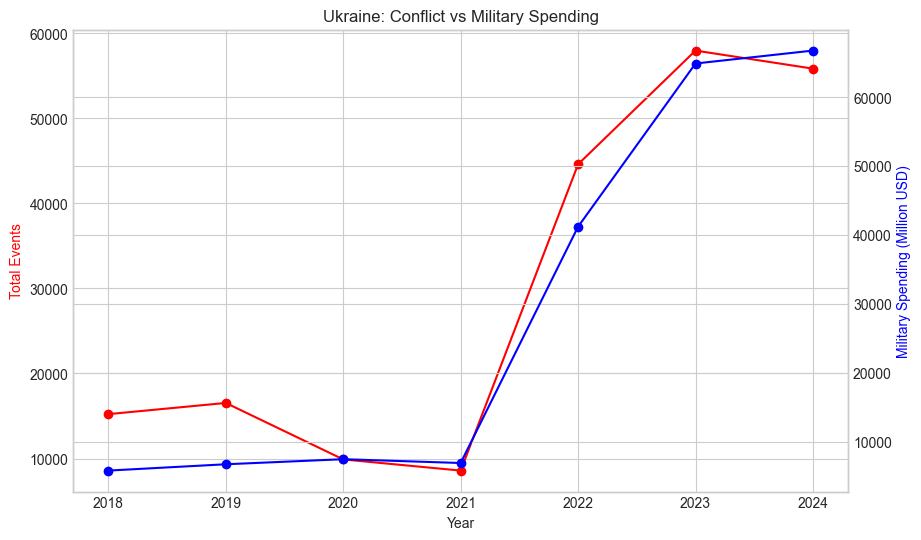

In [21]:
country = "Ukraine"
sub = df[df["country"] == country]

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(sub["year"], sub["total_events"], color="red", marker="o")
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Events", color="red")

ax2 = ax1.twinx()
ax2.plot(sub["year"], sub["milex_constant_usd_m"], color="blue", marker="o")
ax2.set_ylabel("Military Spending (Million USD)", color="blue")

plt.title(f"{country}: Conflict vs Military Spending")

plt.savefig(FIG_DIR / "ukraine_time_series.png")
plt.show()

This time-series chart shows Ukraine's dramatic shift after the Russian invasion in February 2022.

- Military spending rose from $6,882M in 2021 to over $64,000M by 2023, nearly a 10x increase in two years
- Conflict events followed the same trajectory, rising from 8,585 in 2021 to a peak of 57,968 in 2023
- The parallel rise in both lines suggests spending is reactive. Ukraine scaled up defense expenditure in direct response to active conflict rather than as a preventative measure

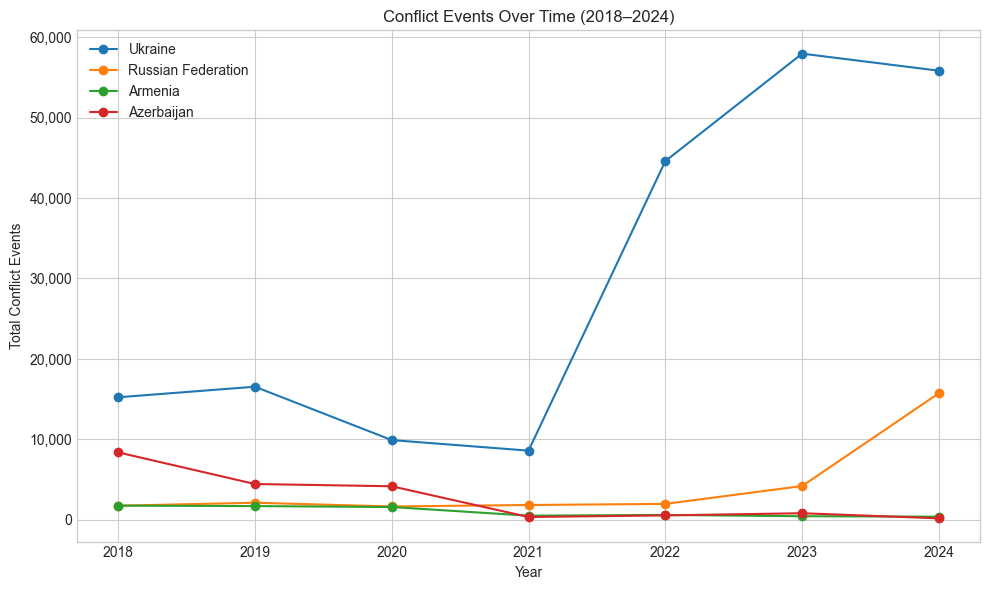

In [22]:
countries = ["Ukraine", "Russian Federation", "Armenia", "Azerbaijan"]

plt.figure(figsize=(10, 6))

for c in countries:
    country_data = df[df["country"] == c]
    plt.plot(country_data["year"], country_data["total_events"], marker="o", label=c)

plt.title("Conflict Events Over Time (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Total Conflict Events")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "multi_country_conflict_trends.png", dpi=150)
plt.show()

This is a conflict events over time time-series plot that compares Ukraine(Blue), Russian Federation(Yellow), Armenia(Green), and Azerbaijan(Red). There is a clear pattern that Ukraine is spiking in dominating the conflict zone after 2021, 2022 and growing. Following that is Russian Federation have a small increase after 2022 and Armenia, Azerbaijan have start decreasing conflict after 2020.  

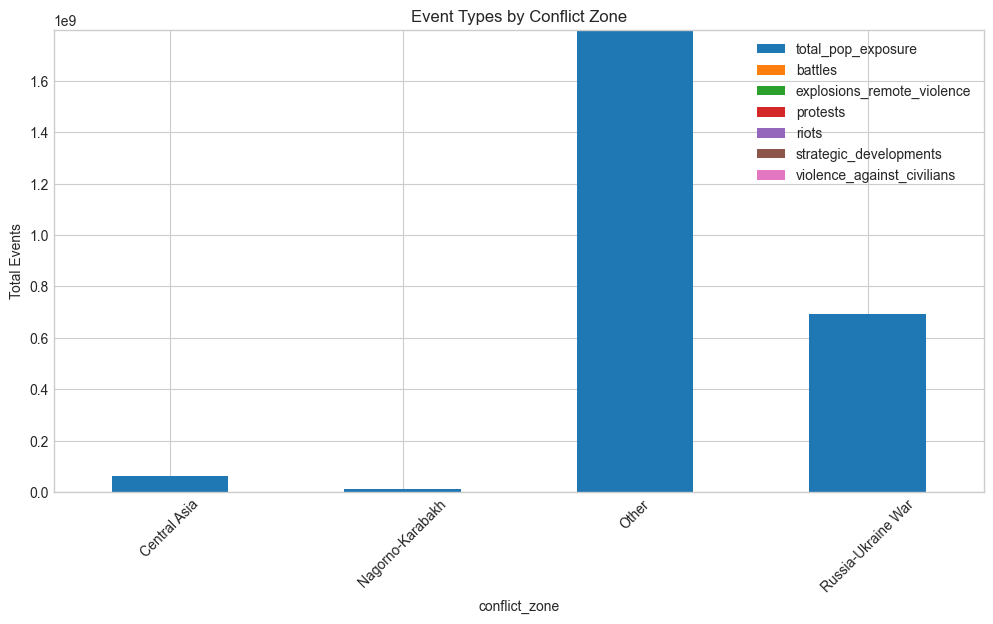

In [23]:
exclude_cols = [
    "country","year","milex_constant_usd_m","milex_share_gdp",
    "wb_milex_pct_gdp","gdp_pct","nato_2pct_threshold",
    "total_events","total_fatalities","conflict_zone",
    "sipri_available","worldbank_available","acled_available"
]

event_cols = [c for c in df.columns if c not in exclude_cols]
event_cols = [c for c in event_cols if df[c].dtype != "O"]

zone_group = df.groupby("conflict_zone")[event_cols].sum()

zone_group.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Event Types by Conflict Zone")
plt.ylabel("Total Events")
plt.xticks(rotation=45)

plt.savefig(FIG_DIR / "event_type_breakdown.png")
plt.show()

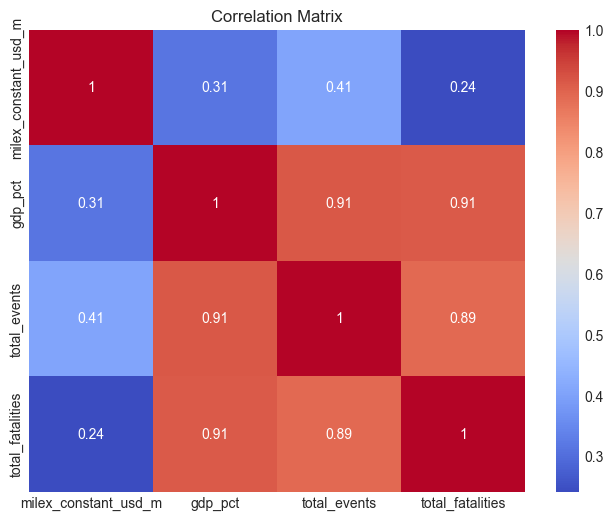

In [24]:
corr = df[[
    "milex_constant_usd_m",
    "gdp_pct",
    "total_events",
    "total_fatalities"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.savefig(FIG_DIR / "correlation_matrix.png")
plt.show()

All four variables show positive correlations with each other.

- Strongest relationship is between total_events and total_fatalities, as expected
- Military spending (both absolute and % GDP) correlates moderately with conflict events
- This provides early visual support for the regression findings in Part 7

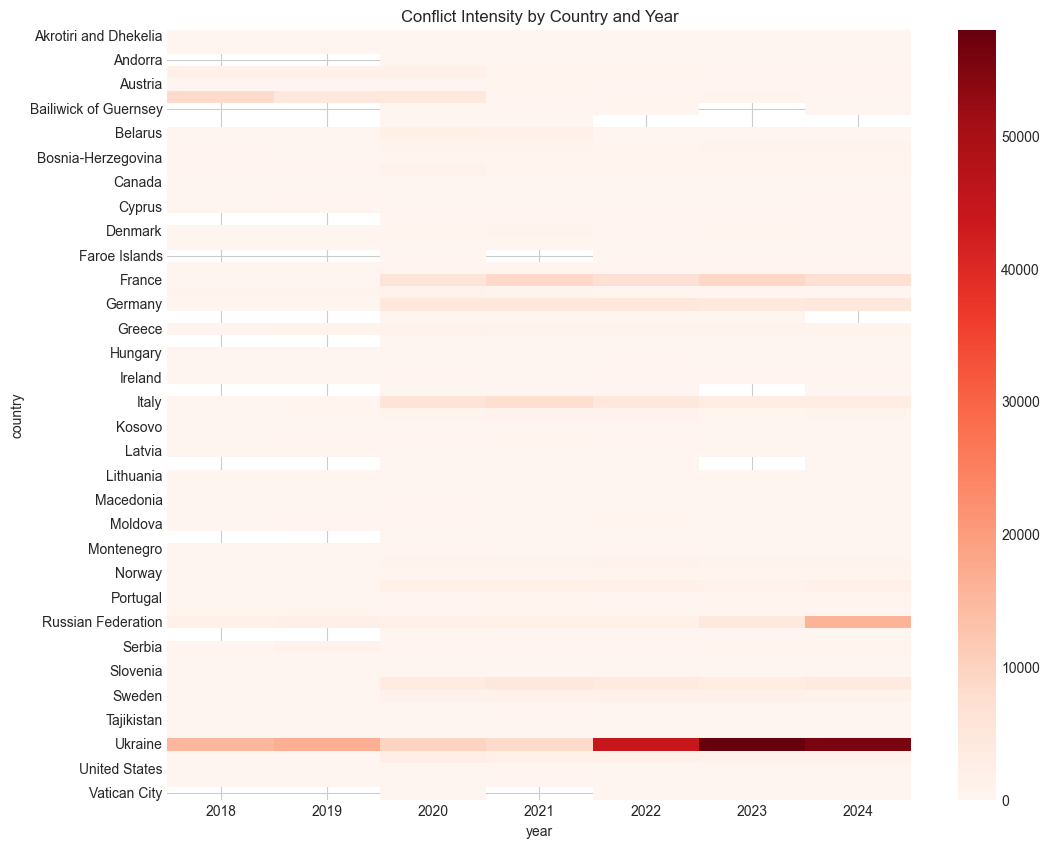

In [25]:
pivot = df.pivot_table(
    values="total_events",
    index="country",
    columns="year",
    aggfunc="sum"
)

plt.figure(figsize=(12,10))

sns.heatmap(pivot, cmap="Reds")

plt.title("Conflict Intensity by Country and Year")

plt.savefig(FIG_DIR / "heatmap_conflict.png")
plt.show()

This heatmap shows conflict intensity by country and year across the full dataset.

- Ukraine's post-2022 rows are visually dominant, confirming it as the dataset's extreme outlier
- Most countries show near-zero activity across all years
- The 2020 Armenia and Azerbaijan spike from the Nagorno-Karabakh war is clearly visible
- A slight uptick in Russian Federation activity is visible after 2022

## Part 7 - Analysis
This section applies three regression analyses and K-Means clustering to the integrated dataset.
The goal is to test whether military spending levels predict conflict intensity across 
Europe and Central Asia from 2018–2024.

In [26]:

df_sorted = df.sort_values(["country", "year"])
df_sorted["milex_lag1"] = df_sorted.groupby("country")["milex_constant_usd_m"].shift(1)
df_sorted["gdp_pct_lag1"] = df_sorted.groupby("country")["gdp_pct"].shift(1)

reg_df = df_sorted.dropna(subset=["total_events", "milex_lag1", "gdp_pct_lag1"])
print(f"observations: {len(reg_df)}")

model = smf.ols("total_events ~ milex_lag1 + gdp_pct_lag1", data=reg_df).fit()
print(model.summary())

reg_df_no_ukr = reg_df[reg_df["country"] != "Ukraine"]
model_no_ukr = smf.ols("total_events ~ milex_lag1 + gdp_pct_lag1", data=reg_df_no_ukr).fit()
print(f"\nR² without Ukraine: {model_no_ukr.rsquared:.3f}")
print(f"milex_lag1 p-value without Ukraine: {model_no_ukr.pvalues['milex_lag1']:.4f}")
print(f"gdp_pct_lag1 p-value without Ukraine: {model_no_ukr.pvalues['gdp_pct_lag1']:.4f}")

observations: 256
                            OLS Regression Results                            
Dep. Variable:           total_events   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     251.4
Date:                Wed, 06 May 2026   Prob (F-statistic):           7.58e-61
Time:                        14:28:18   Log-Likelihood:                -2450.1
No. Observations:                 256   AIC:                             4906.
Df Residuals:                     253   BIC:                             4917.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -1967.7374    277

The pooled lagged regression finds that last year's military spending significantly 
predicts this year's conflict events across all countries.

Key results:
- R² = 0.665, n = 256
- Absolute spending (milex_lag1): p < 0.001
- GDP share (gdp_pct_lag1): p < 0.001

Without Ukraine the model still holds (R² = 0.494, milex p < 0.001), confirming 
the finding is not driven entirely by the war. The % GDP effect becomes 
insignificant without Ukraine, suggesting extreme wartime spending shares 
drive that result.

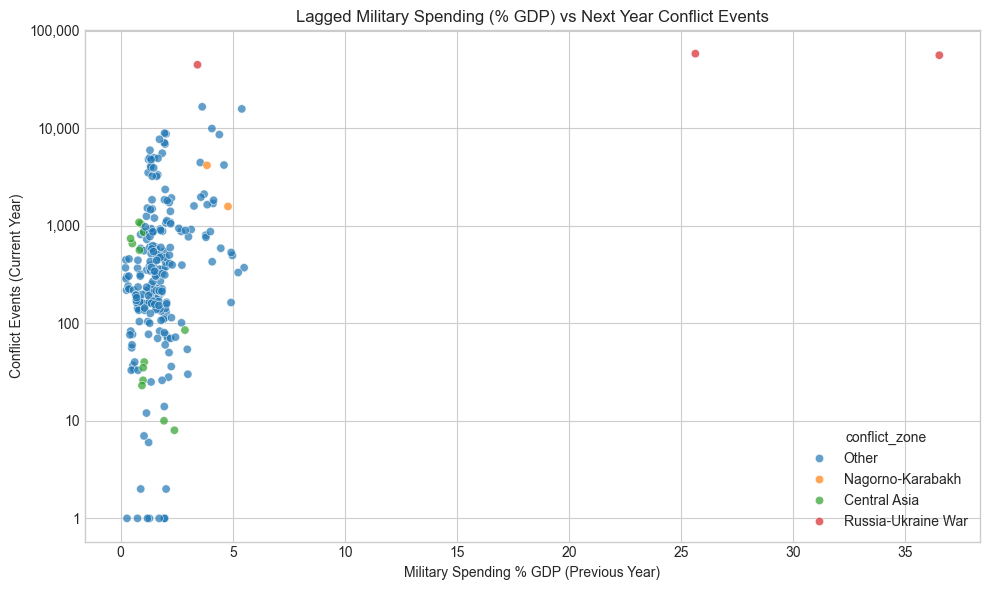

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reg_df, x="gdp_pct_lag1", y="total_events", hue="conflict_zone", alpha=0.7)

plt.title("Lagged Military Spending (% GDP) vs Next Year Conflict Events")
plt.xlabel("Military Spending % GDP (Previous Year)")
plt.ylabel("Conflict Events (Current Year)")
plt.yscale("log")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "regression_scatter.png", dpi=150)
plt.show()

The scatter plot shows the lagged relationship between military spending (% GDP) 
and next year's conflict events on a log scale.

- Russia-Ukraine War points are clear outliers in the upper right
- Most countries cluster in the lower left with low spending and low conflict
- A positive trend is visible across all conflict zones

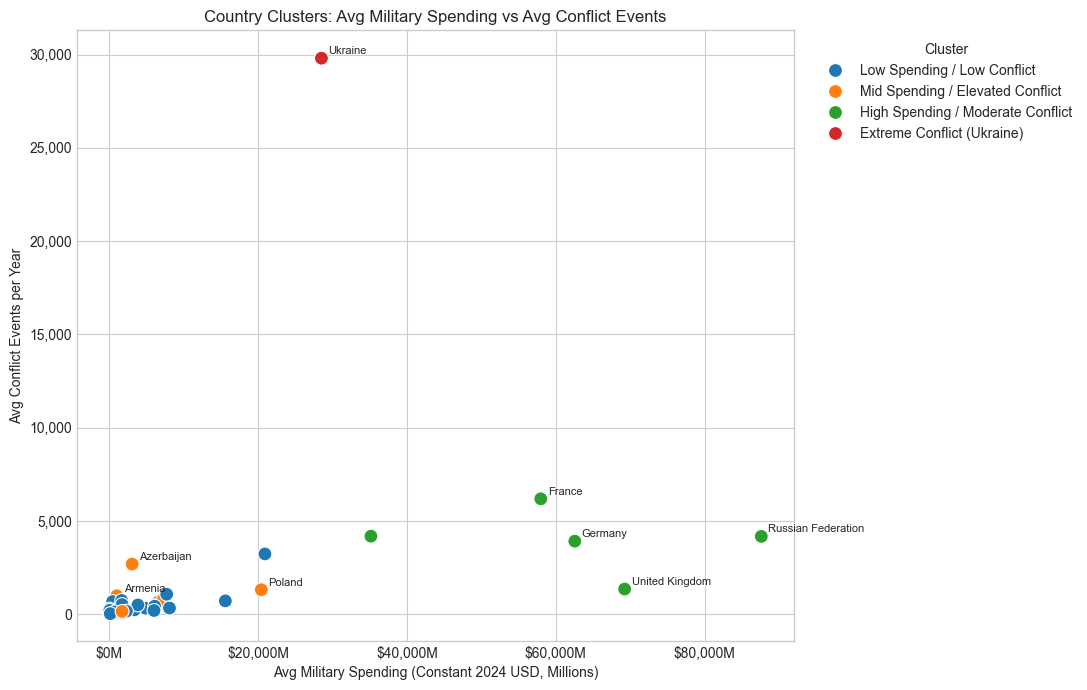

Cluster 0 (Low Spending / Low Conflict): Albania, Austria, Belarus, Belgium, Bosnia-Herzegovina, Bulgaria, Croatia, Cyprus, Denmark, Estonia, Finland, Georgia, Hungary, Ireland, Kazakhstan, Kosovo, Latvia, Lithuania, Luxembourg, Macedonia, Malta, Moldova, Montenegro, Netherlands, Norway, Portugal, Romania, Serbia, Slovakia, Slovenia, Spain, Sweden, Switzerland, Tajikistan
Cluster 1 (High Spending / Moderate Conflict): France, Germany, Italy, Russian Federation, United Kingdom
Cluster 2 (Extreme Conflict (Ukraine)): Ukraine
Cluster 3 (Mid Spending / Elevated Conflict): Armenia, Azerbaijan, Greece, Poland, Uzbekistan


In [28]:

cluster_df = df.groupby("country").agg(
    avg_spending=("milex_constant_usd_m", "mean"),
    avg_gdp_pct=("gdp_pct", "mean"),
    avg_events=("total_events", "mean"),
    avg_fatalities=("total_fatalities", "mean")
).dropna(subset=["avg_spending", "avg_gdp_pct"]).fillna(0)

X_scaled = StandardScaler().fit_transform(cluster_df)
cluster_df["cluster"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)

cluster_labels = {
    0: "Low Spending / Low Conflict",
    1: "High Spending / Moderate Conflict",
    2: "Extreme Conflict (Ukraine)",
    3: "Mid Spending / Elevated Conflict"
}
cluster_df["cluster_label"] = cluster_df["cluster"].map(cluster_labels)

highlight = ["Ukraine", "Russian Federation", "France", "Germany",
             "Armenia", "Azerbaijan", "Poland", "United Kingdom"]

plt.figure(figsize=(11, 7))
sns.scatterplot(data=cluster_df, x="avg_spending", y="avg_events",
                hue="cluster_label", palette="tab10", s=100)

for country, row in cluster_df.iterrows():
    if country in highlight:
        plt.annotate(country, (row["avg_spending"], row["avg_events"]),
                    fontsize=8, xytext=(5, 3), textcoords="offset points")

plt.title("Country Clusters: Avg Military Spending vs Avg Conflict Events")
plt.xlabel("Avg Military Spending (Constant 2024 USD, Millions)")
plt.ylabel("Avg Conflict Events per Year")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

for c in range(4):
    countries_in = cluster_df[cluster_df["cluster"] == c].index.tolist()
    print(f"Cluster {c} ({cluster_labels[c]}): {', '.join(sorted(countries_in))}")

K-Means identifies four distinct country profiles:

- Cluster 0 (Low Spending / Low Conflict): small and neutral European and 
  post-Soviet states
- Cluster 1 (High Spending / Moderate Conflict): major powers — France, 
  Germany, Russia, UK
- Cluster 2 (Extreme Conflict): Ukraine alone, isolated by active war
- Cluster 3 (Mid Spending / Elevated Conflict): regional conflict countries 
  like Armenia and Azerbaijan alongside NATO eastern flank states like Poland

### Supporting Regressions

In [29]:
df_sorted["milex_pct_change"] = df_sorted.groupby("country")["milex_constant_usd_m"].pct_change() * 100
reg_df2 = df_sorted.dropna(subset=["total_events", "milex_pct_change"])

model2 = smf.ols("total_events ~ milex_pct_change", data=reg_df2).fit()
print(f"R²: {model2.rsquared:.3f}")
print(f"milex_pct_change p-value: {model2.pvalues['milex_pct_change']:.4f}")
print(f"coefficient: {model2.params['milex_pct_change']:.4f}")

R²: 0.194
milex_pct_change p-value: 0.0000
coefficient: 75.9102


A 1% increase in military spending predicts approximately 76 additional 
conflict events the following year.

- p < 0.001, R² = 0.194
- Lower R² than the absolute spending model but confirms that spending 
  growth rate, not just spending level, predicts conflict intensity

In [30]:
reg_df_fatal = df_sorted.dropna(subset=["total_fatalities", "milex_lag1", "gdp_pct_lag1"])

model_fatal = smf.ols("total_fatalities ~ milex_lag1 + gdp_pct_lag1", data=reg_df_fatal).fit()
print(f"R²: {model_fatal.rsquared:.3f}")
print(f"milex_lag1 p-value: {model_fatal.pvalues['milex_lag1']:.4f}")
print(f"gdp_pct_lag1 p-value: {model_fatal.pvalues['gdp_pct_lag1']:.4f}")
print(f"milex_lag1 coef: {model_fatal.params['milex_lag1']:.6f}")
print(f"gdp_pct_lag1 coef: {model_fatal.params['gdp_pct_lag1']:.4f}")

reg_df_fatal_no_ukr = reg_df_fatal[reg_df_fatal["country"] != "Ukraine"]
model_fatal_no_ukr = smf.ols("total_fatalities ~ milex_lag1 + gdp_pct_lag1", data=reg_df_fatal_no_ukr).fit()
print(f"\nR² without Ukraine: {model_fatal_no_ukr.rsquared:.3f}")
print(f"milex_lag1 p-value without Ukraine: {model_fatal_no_ukr.pvalues['milex_lag1']:.4f}")
print(f"gdp_pct_lag1 p-value without Ukraine: {model_fatal_no_ukr.pvalues['gdp_pct_lag1']:.4f}")

R²: 0.730
milex_lag1 p-value: 0.1291
gdp_pct_lag1 p-value: 0.0000
milex_lag1 coef: -0.015363
gdp_pct_lag1 coef: 1787.7322

R² without Ukraine: 0.086
milex_lag1 p-value without Ukraine: 0.1001
gdp_pct_lag1 p-value without Ukraine: 0.0001


The fatalities model is the strongest overall but is heavily Ukraine-driven.

- Full model: R² = 0.730, gdp_pct_lag1 p < 0.001
- Without Ukraine: R² collapses to 0.086
- gdp_pct_lag1 remains significant without Ukraine (p = 0.0001), suggesting 
  GDP share still predicts fatalities across the broader region at a lower level

Pre-2022:
  R²: 0.212
  milex_lag1 coef: 0.0337, p = 0.0022
  gdp_pct_lag1 coef: 758.1459, p = 0.0001

Post-2022:
  R²: 0.711
  milex_lag1 coef: 0.0504, p = 0.0085
  gdp_pct_lag1 coef: 1673.6727, p = 0.0000


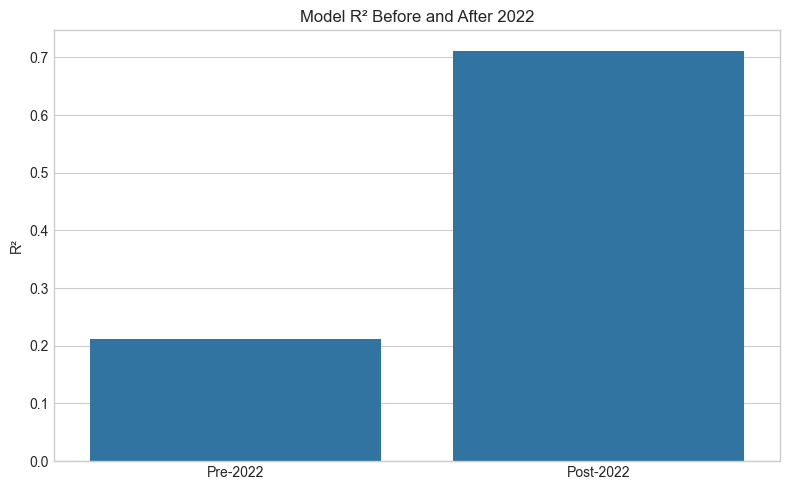

In [31]:
pre_2022 = reg_df[reg_df["year"] < 2022]
post_2022 = reg_df[reg_df["year"] >= 2022]

model_pre = smf.ols("total_events ~ milex_lag1 + gdp_pct_lag1", data=pre_2022).fit()
model_post = smf.ols("total_events ~ milex_lag1 + gdp_pct_lag1", data=post_2022).fit()

print("Pre-2022:")
print(f"  R²: {model_pre.rsquared:.3f}")
print(f"  milex_lag1 coef: {model_pre.params['milex_lag1']:.4f}, p = {model_pre.pvalues['milex_lag1']:.4f}")
print(f"  gdp_pct_lag1 coef: {model_pre.params['gdp_pct_lag1']:.4f}, p = {model_pre.pvalues['gdp_pct_lag1']:.4f}")

print("\nPost-2022:")
print(f"  R²: {model_post.rsquared:.3f}")
print(f"  milex_lag1 coef: {model_post.params['milex_lag1']:.4f}, p = {model_post.pvalues['milex_lag1']:.4f}")
print(f"  gdp_pct_lag1 coef: {model_post.params['gdp_pct_lag1']:.4f}, p = {model_post.pvalues['gdp_pct_lag1']:.4f}")

plt.figure(figsize=(8, 5))
periods = ["Pre-2022", "Post-2022"]
r2_vals = [model_pre.rsquared, model_post.rsquared]
sns.barplot(x=periods, y=r2_vals)
plt.title("Model R² Before and After 2022")
plt.ylabel("R²")
plt.tight_layout()
plt.savefig(FIG_DIR / "structural_break.png", dpi=150)
plt.show()

Model fit more than tripled after the Russia-Ukraine war began.

- Pre-2022: R² = 0.212
- Post-2022: R² = 0.711

Both predictors are significant in both periods but coefficients are 
substantially larger post-2022. This confirms the war fundamentally 
strengthened the spending-conflict relationship across the entire region, 
not just in Ukraine.